In [41]:
import pandas as pd
import numpy as np
from pathlib import Path

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import umap

# Viz
import matplotlib.pyplot as plt
import seaborn as sns # for colorblind palette

# KNN metric evaluation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


In [3]:
parquet_path = Path("../../data/processed/particle_labeled.parquet")
nfi_df = pd.read_parquet(parquet_path)
nfi_df.shape

(2801667, 95)

In [4]:
# Isolate element columns
element_cols = list(nfi_df.loc[:, 'ac':'zr'].columns)

In [5]:
# Use non-zero rates from particle_eda.ipynb to filter out non-informative elements
nonzero_rates = (nfi_df[element_cols] > 0).mean().sort_values(ascending=False)
informative_cols = sorted(nonzero_rates[nonzero_rates > 0.01].index.tolist())
len(informative_cols)


27

In [6]:
# Binary filter
binary = nfi_df[nfi_df['label'].isin(['GSR', 'Non_GSR'])]

# Sample 10% to save my laptop  :)
sample, _ = train_test_split(
    binary, 
    train_size=0.1, 
    stratify=binary['label'], # stratify to maintain class balance
    random_state=42
)

f"Sample size: {len(sample):,}"

'Sample size: 229,498'

In [7]:
X_sample = sample[informative_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

In [8]:
# UMAP
reducer = umap.UMAP(
    n_neighbors=15, # balance local vs. global structure
    min_dist=0.1, # tightness of clusters
    n_components=2, # 2D viz
    metric='euclidean', # default measuring technique for continuous data
    random_state=42, # reproducibility: keep at 42 for comparing w/ different params & ambiguous class overlay
    low_memory=True
)
X_umap = reducer.fit_transform(X_scaled)

c:\git\datascience-capstone\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


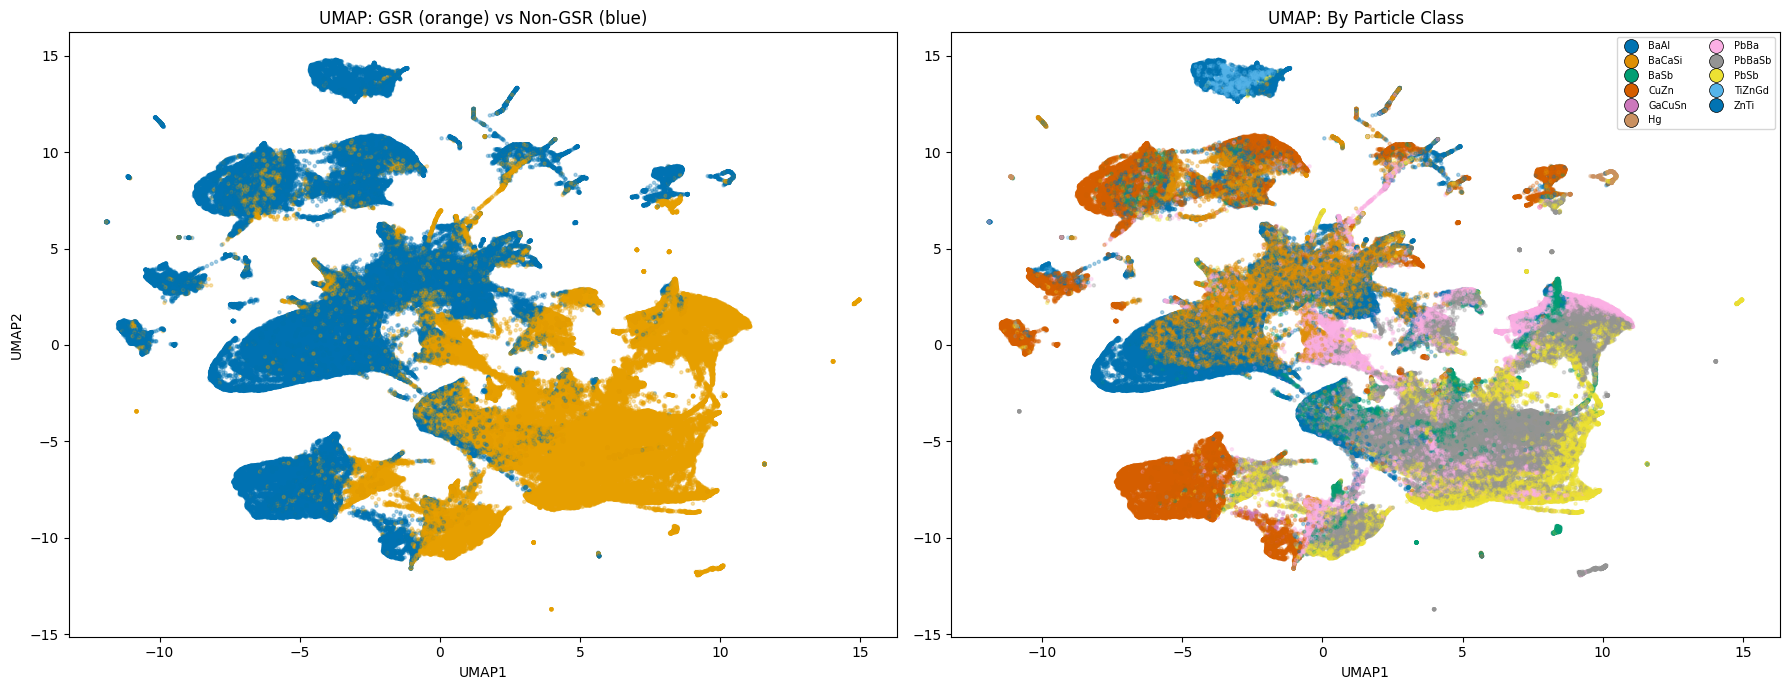

In [43]:
# Plot the UMAP results (2 plots) colored by: 1) binary label; 2) particle class
le = LabelEncoder()
class_encoded = le.fit_transform(sample["final_class"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorblind friendly colors
colors = (
    sample["label"]
    .map({"GSR": "#E69F00", "Non_GSR": "#0072B2"})  # orange  # blue
    .values
)
palette = sns.color_palette("colorblind", n_colors=len(le.classes_))
point_colors = [palette[i] for i in class_encoded]

# scatter plot for binary labels
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.3, s=5)
axes[0].set_title("UMAP: GSR (orange) vs Non-GSR (blue)")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# scatter plot for particle classes
scatter = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=point_colors, alpha=0.3, s=5)
axes[1].set_title("UMAP: By Particle Class")
axes[1].set_xlabel("UMAP1")

# custom legend for particle classes
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=cls,
    )
    for i, cls in enumerate(sorted(le.classes_))
]
axes[1].legend(
    handles=handles,
    loc="upper right",
    fontsize=7,
    ncol=2,
    markerscale=1
)

plt.tight_layout()
plt.show()

In [10]:
# Get ambiguous class
ambiguous = nfi_df[nfi_df['label'] == 'Ambiguous']
ambiguous['final_class'].value_counts()

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64

In [11]:
# Sample 10% of ambiguous class
amb_sample, _ = train_test_split(ambiguous, train_size=0.1, random_state=42)

X_amb = scaler.transform(amb_sample[informative_cols].fillna(0).values)
X_amb_umap = reducer.transform(X_amb)

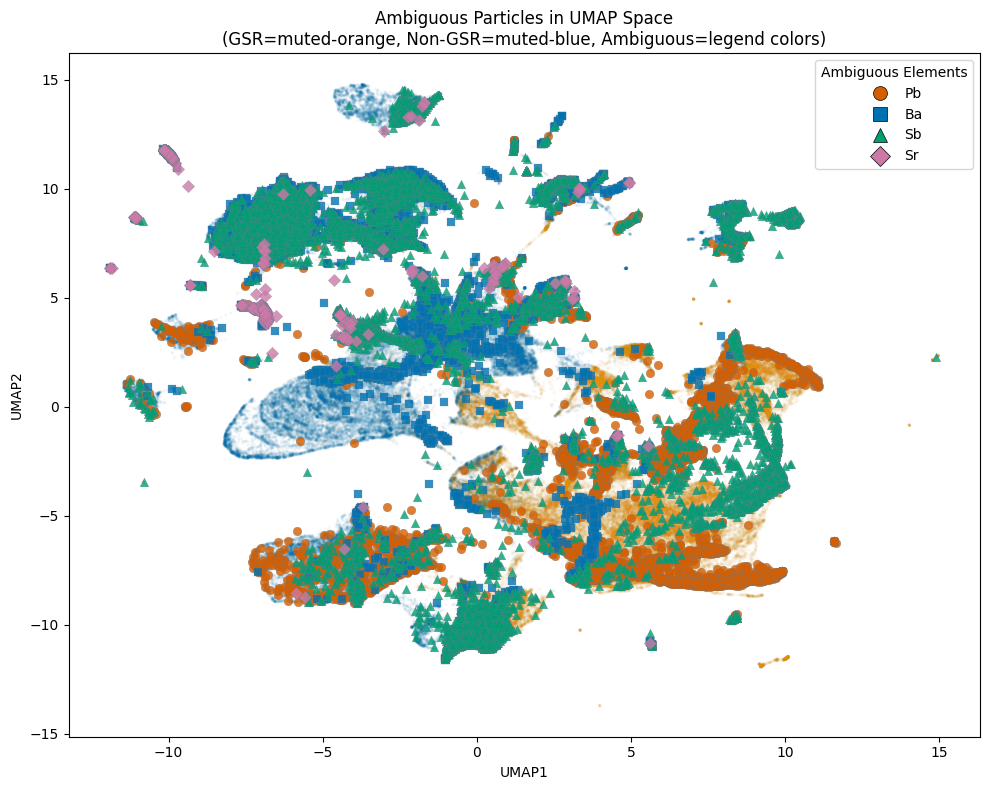

In [45]:
# Colorblind friendly colors for ambiguous classes
colors_muted = sample["label"].map({"GSR": palette[1], "Non_GSR": palette[0]}).values
amb_classes = [
    ("Pb", "#D55E00", "o"),  # vermillion
    ("Ba", "#0072B2", "s"),  # blue
    ("Sb", "#009E73", "^"),  # green
    ("Sr", "#CC79A7", "D"),  # purple
]

# replot binary UMAP w/ muted colors
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=colors_muted, alpha=0.03, s=2)

# Overlay ambiguous class
for cls, color, marker in amb_classes:
    mask = amb_sample["final_class"] == cls
    if mask.sum() > 0:
        ax.scatter(
            X_amb_umap[mask, 0],
            X_amb_umap[mask, 1],
            c=color,
            marker=marker,
            s=40,
            alpha=0.8,
            edgecolors="slategray",
            linewidths=0.2,
            label=cls,
        )

# custom legend for ambiguous elements
handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="None",
        color="w",
        markerfacecolor=color,
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=cls,
    )
    for cls, color, marker in amb_classes
]
ax.legend(handles=handles, fontsize=10, title="Ambiguous Elements")
ax.set_title(
    "Ambiguous Particles in UMAP Space\n(GSR=muted-orange, Non-GSR=muted-blue, Ambiguous=legend colors)"
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.show()

In [40]:
# kNN classification accuracy
# Tests whether neighbors in the embedding share labels
X_umap_np = np.array(X_umap)
knn = KNeighborsClassifier(n_neighbors=15)
labels = np.array(sample['label'].values)
knn_umap = cross_val_score(knn, X_umap_np, labels, cv=5, scoring='accuracy').mean()

f"kNN classification accuracy: {knn_umap * 100:.1f}%"

'kNN classification accuracy: 94.0%'

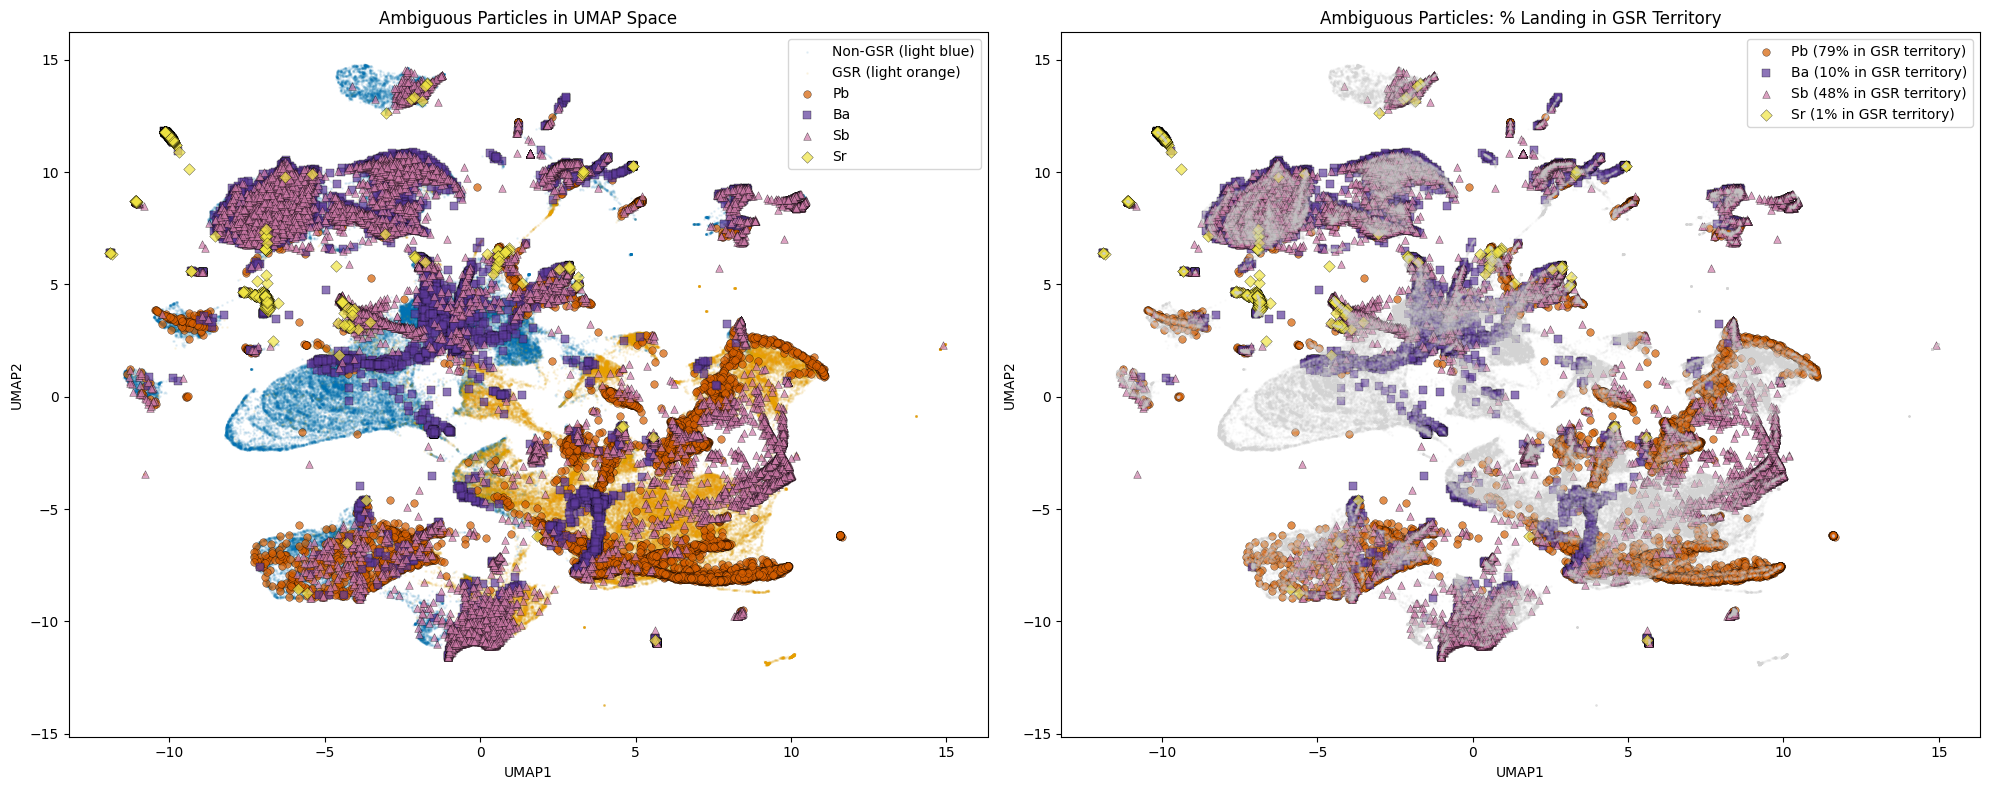

In [ ]:
# Improve the ambiguous particles UMAP overlay viz
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left panel: ambiguous overlaid on binary
gsr_mask = sample["label"] == "GSR"
nongsr_mask = sample["label"] == "Non_GSR"

# non-gsr
axes[0].scatter(
    X_umap[nongsr_mask, 0],
    X_umap[nongsr_mask, 1],
    c="#0072B2",
    alpha=0.07,
    s=1,
    label="Non-GSR (light blue)",
)
# gsr
axes[0].scatter(
    X_umap[gsr_mask, 0], X_umap[gsr_mask, 1], c="#E69F00", alpha=0.07, s=1, label="GSR (light orange)"
)
# ambiguous (colorblind friendly)
amb_styles = [
    ("Pb", "#D55E00", "o", 30),  # vermillion circles
    ("Ba", "#5D3A9B", "s", 30),  # violet squares
    ("Sb", "#CC79A7", "^", 30),  # pink triangles
    ("Sr", "#F0E442", "D", 35),  # yellow diamonds
]

for cls, color, marker, sz in amb_styles:
    mask = amb_sample["final_class"] == cls
    if mask.sum() > 0:
        axes[0].scatter(
            X_amb_umap[mask, 0],
            X_amb_umap[mask, 1],
            c=color,
            s=sz,
            alpha=0.7,
            label=cls,
            marker=marker,
            edgecolors="black",
            linewidths=0.3,
        )

axes[0].legend(fontsize=10, loc="upper right")
axes[0].set_title("Ambiguous Particles in UMAP Space")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# Right panel: split by ambiguous class
for i, (cls, color, marker, sz) in enumerate(amb_styles):
    mask = amb_sample["final_class"] == cls
    if mask.sum() == 0:
        continue

    # Count how many land in GSR-heavy vs Non-GSR-heavy regions
    # using a kNN vote from the embedded training
    knn = KNeighborsClassifier(n_neighbors=15)
    knn.fit(X_umap, sample["label"].values)
    amb_pred = knn.predict(X_amb_umap[mask])
    gsr_pct = (amb_pred == "GSR").mean() * 100

    axes[1].scatter(
        X_amb_umap[mask, 0],
        X_amb_umap[mask, 1],
        c=color,
        s=sz,
        alpha=0.7,
        marker=marker,
        edgecolors="black",
        linewidths=0.3,
        label=f"{cls} ({gsr_pct:.0f}% in GSR territory)",
    )

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c="lightgray", alpha=0.05, s=1)
axes[1].legend(fontsize=10, loc="upper right")
axes[1].set_title("Ambiguous Particles: % Landing in GSR Territory")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

In [51]:
# Hyperparameter exploratory tuning